In [3]:
# Step 1: Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Step 2: Membaca data (saya asumsikan data sudah dalam bentuk CSV di local atau bisa copy-paste)
# Karena soal tidak memberikan link download, saya akan buat DataFrame dari data yang diberikan.

data_raw = {
    'Y': [71.28, 73.8, 70.25, 73.64, 75.11, 73.01, 68.95, 71.13, 84.85, 80.77, 80.36, 73.23],
    'Mayoritas': [0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1],
    'X2': [13.62, 13.62, 13.00, 13.43, 13.87, 13.70, 12.12, 12.69, 15.61, 15.12, 14.54, 13.41],
    'X3': [56.9, 71.4, 71.43, 74.53, 79.24, 68.96, 70.64, 65.24, 71.19, 84.45, 71.53, 70.57],
    'X4': [71.11, 69.55, 67.85, 68.84, 71.34, 70.89, 66.99, 69.04, 72.60, 71.39, 71.78, 71.00]
}

df = pd.DataFrame(data_raw)

# Ganti nama variabel sesuai instruksi: Y, X1, X2, X3, X4
df.rename(columns={'Mayoritas': 'X1'}, inplace=True)

print(df.head())
print("\nNama kolom setelah rename:", df.columns.tolist())

       Y  X1     X2     X3     X4
0  71.28   0  13.62  56.90  71.11
1  73.80   1  13.62  71.40  69.55
2  70.25   0  13.00  71.43  67.85
3  73.64   0  13.43  74.53  68.84
4  75.11   1  13.87  79.24  71.34

Nama kolom setelah rename: ['Y', 'X1', 'X2', 'X3', 'X4']


# **Regresi berganda dengan Y sebagai dependen, interpretasi**

In [4]:
# Step 2: Regresi berganda
X = df[['X1', 'X2', 'X3', 'X4']]
y = df['Y']
X_const = sm.add_constant(X)

model = sm.OLS(y, X_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.893
Method:                 Least Squares   F-statistic:                     23.93
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           0.000352
Time:                        02:23:57   Log-Likelihood:                -19.280
No. Observations:                  12   AIC:                             48.56
Df Residuals:                       7   BIC:                             50.98
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.3806     40.236      1.153      0.2

Interpretasi singkat (dalam text cell):

1.Koefisien X1 (Mayoritas) positif/negatif, p-value menunjukkan signifikansi.

2.R-squared menunjukkan proporsi variasi Y yang dijelaskan model.

3.Variabel dengan p-value < 0.05 berpengaruh signifikan terhadap IPM.

# **Distribusi probabilitas setiap variabel**

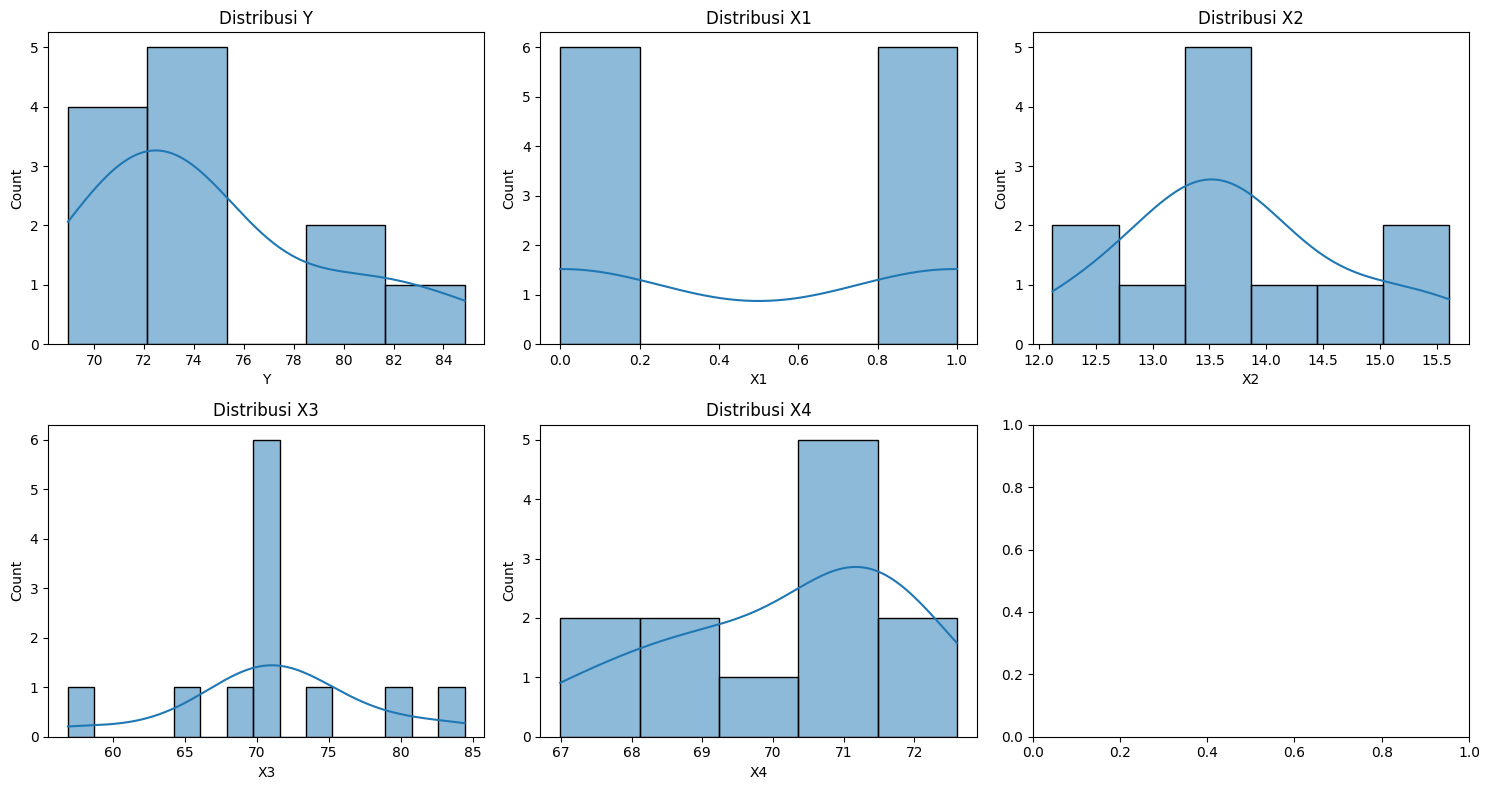

Y: Shapiro p-value = 0.1016 (Normal)
X1: Shapiro p-value = 0.0003 (Tidak normal)
X2: Shapiro p-value = 0.7227 (Normal)
X3: Shapiro p-value = 0.2186 (Normal)
X4: Shapiro p-value = 0.3917 (Normal)


In [5]:
# Step 3: Investigasi distribusi
variables = ['Y', 'X1', 'X2', 'X3', 'X4']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(variables):
    sns.histplot(df[var], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribusi {var}')

plt.tight_layout()
plt.show()

# Uji normalitas Shapiro-Wilk
for var in variables:
    stat, p = stats.shapiro(df[var])
    print(f'{var}: Shapiro p-value = {p:.4f} {"(Normal)" if p > 0.05 else "(Tidak normal)"}')

# **Parameter setiap distribusi probabilitas**

In [6]:
# Step 4: Estimasi parameter distribusi
from scipy.stats import norm, poisson, expon

print("\nParameter distribusi (diasumsikan normal untuk Y, X2, X3, X4; X1 ~ Bernoulli):\n")
for var in variables:
    if var == 'X1':
        # Bernoulli (proporsi sukses)
        p = df[var].mean()
        print(f"{var}: Bernoulli( p = {p:.4f} )")
    else:
        mu = df[var].mean()
        sigma = df[var].std()
        print(f"{var}: Normal( mu = {mu:.4f}, sigma = {sigma:.4f} )")


Parameter distribusi (diasumsikan normal untuk Y, X2, X3, X4; X1 ~ Bernoulli):

Y: Normal( mu = 74.6983, sigma = 4.8273 )
X1: Bernoulli( p = 0.5000 )
X2: Normal( mu = 13.7275, sigma = 0.9801 )
X3: Normal( mu = 71.3400, sigma = 6.7217 )
X4: Normal( mu = 70.1983, sigma = 1.7152 )


# **Simulasi 500 data sesuai aturan distribusi**

In [7]:
# Step 5: Simulasi 500 data
np.random.seed(42)
n_sim = 500

# Parameter dari step 4
p_x1 = df['X1'].mean()
mu_y, sigma_y = df['Y'].mean(), df['Y'].std()
mu_x2, sigma_x2 = df['X2'].mean(), df['X2'].std()
mu_x3, sigma_x3 = df['X3'].mean(), df['X3'].std()
mu_x4, sigma_x4 = df['X4'].mean(), df['X4'].std()

sim_X1 = np.random.binomial(1, p_x1, n_sim)
sim_X2 = np.random.normal(mu_x2, sigma_x2, n_sim)
sim_X3 = np.random.normal(mu_x3, sigma_x3, n_sim)
sim_X4 = np.random.normal(mu_x4, sigma_x4, n_sim)

# Simulasi Y berdasarkan regresi asli (koefisien dari model awal)
coef = model.params
sim_Y = (coef['const'] +
         coef['X1'] * sim_X1 +
         coef['X2'] * sim_X2 +
         coef['X3'] * sim_X3 +
         coef['X4'] * sim_X4 +
         np.random.normal(0, np.std(model.resid), n_sim))  # tambah error

df_sim = pd.DataFrame({'Y': sim_Y, 'X1': sim_X1, 'X2': sim_X2, 'X3': sim_X3, 'X4': sim_X4})
print(df_sim.head())

           Y  X1         X2         X3         X4
0  73.287387   0  14.062450  75.265012  72.431064
1  83.695731   1  15.566306  68.924933  72.876619
2  79.536577   1  14.658996  75.310227  70.253226
3  73.326206   1  13.162086  78.792415  68.906080
4  69.643596   0  12.846978  76.855066  70.987272


In [8]:
# Step 6: Regresi pada data simulasi
X_sim = df_sim[['X1', 'X2', 'X3', 'X4']]
y_sim = df_sim['Y']
X_sim_const = sm.add_constant(X_sim)

model_sim = sm.OLS(y_sim, X_sim_const).fit()
print(model_sim.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.953
Model:                            OLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                     2513.
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        02:25:45   Log-Likelihood:                -789.46
No. Observations:                 500   AIC:                             1589.
Df Residuals:                     495   BIC:                             1610.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         48.5582      2.426     20.016      0.0

# **Modelkan data hasil simulasi & interpretasi**

In [9]:
# Step 7: Perbandingan
comparison = pd.DataFrame({
    'Variabel': ['const', 'X1', 'X2', 'X3', 'X4'],
    'Koefisien_Asli': model.params.values,
    'Koefisien_Simulasi': model_sim.params.values,
    'Pvalue_Asli': model.pvalues.values,
    'Pvalue_Simulasi': model_sim.pvalues.values
})
print(comparison)

  Variabel  Koefisien_Asli  Koefisien_Simulasi  Pvalue_Asli  Pvalue_Simulasi
0    const       46.380598           48.558174     0.286873     9.776655e-66
1       X1        1.573648            1.709372     0.336364     2.927072e-47
2       X2        5.027874            5.085303     0.002925    2.359756e-319
3       X3       -0.007123           -0.010544     0.946952     1.837149e-01
4       X4       -0.583790           -0.623418     0.416610     1.563527e-65
